# Práctico Mabwiser

Adaptado de los tutoriales disponibles en: https://github.com/fidelity/mabwiser/tree/master/examples

## Reinforcement Learning

Un agente de RL busca tomar acciones que logren maximizar la ganancia acumulativa.

![RL setup](https://github.com/bamine/recsys-summer-school/raw/12e57cc4fd1cb26164d2beebf3ca29ebe2eab960/notebooks/images/rl-setup.png)


## Exploration vs. Exploitation

Se busca encontrar un balance entre la exploration (decidir tomar una acción para ganar conocimiento) y exploitation (decidir la acción que se calcula que tendrá la mejor ganancia).

![texto alternativo](https://miro.medium.com/max/1400/1*_5dltx4BcI8rRmCK2Sq_kw.png)

## Importar paquetes necesarios

In [ ]:
!pip install mabwiser
# -*- coding: utf-8 -*-

import pandas as pd
from sklearn.preprocessing import StandardScaler

from mabwiser.mab import MAB, LearningPolicy, NeighborhoodPolicy

import random
from mabwiser.simulator import Simulator

from time import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


## Problema con contexto:

Una plataforma de comercio virtual cuenta con 5 _ads_ y quiere determinar cuál de estos generará mayor _revenue_ para un usuario en específico. Para esto, se cuenta con información histórica de _revenues_ obtenidos por otros usuarios en distintos _ads_ junto con la información de la edad, la razón de clicks y si cada usuario es subscriptor o no.

In [ ]:
# Arms
ads = [1, 2, 3, 4, 5]

# Historical data of ad decisions with corresponding revenues and context information
train_df = pd.DataFrame({'ad': [1, 1, 1, 2, 4, 5, 3, 3, 2, 1, 4, 5, 3, 2, 5],
                         'revenues': [10, 17, 22, 9, 4, 20, 7, 8, 20, 9, 50, 5, 7, 12, 10],
                         'age': [22, 27, 39, 48, 21, 20, 19, 37, 52, 26, 18, 42, 55, 57, 38],
                         'click_rate': [0.2, 0.6, 0.99, 0.68, 0.15, 0.23, 0.75, 0.17,
                                        0.33, 0.65, 0.56, 0.22, 0.19, 0.11, 0.83],
                         'subscriber': [1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0]}
                        )

# Test data to for new prediction
test_df = pd.DataFrame({'age': [37, 52], 'click_rate': [0.5, 0.6], 'subscriber': [0, 1]})
test_df_revenue = pd.Series([7, 13])

# Scale the training and test data
scaler = StandardScaler()
train = scaler.fit_transform(train_df[['age', 'click_rate', 'subscriber']].values.astype('float64'))
test = scaler.transform(test_df.values.astype('float64'))

In [ ]:
test

array([[ 0.16898074,  0.19942764, -1.22474487],
       [ 1.28723564,  0.55554842,  0.81649658]])

In [ ]:
########################################################
# KNearest Neighborhood Policy with UCB1 Learning Policy
########################################################

# KNearest context policy with k equals to 5 and ucb1 learning with alpha of 1.25
knearest = MAB(arms=ads,
               learning_policy=LearningPolicy.UCB1(alpha=1.25),
               neighborhood_policy=NeighborhoodPolicy.KNearest(k=5))

# Learn from previous ads shown and revenues generated
knearest.fit(decisions=train_df['ad'], rewards=train_df['revenues'], contexts=train)

# Predict the next best ad to show
prediction = knearest.predict(test)

# Expectation of each ad based on learning from past ad revenues
expectations = knearest.predict_expectations(test)

# Results
print("KNearest: ", prediction, " ", expectations)
assert(prediction == [5, 1])

# Online update of model
knearest.partial_fit(decisions=prediction, rewards=test_df_revenue, contexts=test)

# Updating of the model with new arm
knearest.add_arm(6)

KNearest:  [5, 1]   [{1: np.float64(14.5857953014744), 2: np.float64(11.242653222492628), 3: 0, 4: 0, 5: np.float64(16.5857953014744)}, {1: np.float64(24.242653222492628), 2: np.float64(17.5857953014744), 3: np.float64(10.242653222492628), 4: 0, 5: np.float64(7.242653222492627)}]


### Actividad 1:
Suponga que a este mismo usuario, se le presenta el nuevo _ad_, $6$, obteniendo un revenue de $40$. Usando el método _partial\_fit_ simule este caso e imprima las nuevas expectations. Comente los resultados obtenidos.

In [ ]:
prediction

[5, 1]

In [ ]:
test_df_revenue = pd.Series([40])
prediction = [6]

# Online update of model
knearest.partial_fit(decisions=prediction, rewards=test_df_revenue, contexts=test[0:1])

# Recalcular expectations DESPUÉS del partial_fit
new_expectations = knearest.predict_expectations(test)
print("KNearest post ad 6: ", new_expectations)

KNearest post ad 6:  [{1: np.float64(14.5857953014744), 2: 0, 3: 0, 4: 0, 5: np.float64(9.242653222492628), 6: np.float64(41.5857953014744)}, {1: np.float64(19.0857953014744), 2: np.float64(17.5857953014744), 3: 0, 4: 0, 5: np.float64(7.242653222492627), 6: 0}]


Tras el 'partial_fit', el ad 6 obtiene una expectativa de 41.6 para el usuario 1, convirtiéndose en la opción preferida. Esto refleja el único reward observado (40) más el bonus de UCB1 por incertidumbre. Para el usuario 2, la expectativa del ad 6 permanece en 0 porque KNearest es un método contextual: el aprendizaje solo se transfiere a usuarios con perfil similar al que recibió el ad, y ambos usuarios tienen contextos suficientemente distintos.



## Problema sin contexto:

El sitio ahora quiere elegir entre dos posibles opciones de diseño para su _homepage_. Para esto tiene datos históricos del revenue aportado por cada diseño, pero no cuenta con ningún dato acerca de los usuarios.

In [ ]:
# Arms
options = [1, 2]

# Historical data of layouts decisions and corresponding rewards
layouts = [1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1]
revenues = [10, 17, 22, 9, 4, 0, 7, 8, 20, 9, 50, 5, 7, 12, 10]

In [ ]:
###################################
# Epsilon Greedy Learning Policy
###################################

# Epsilon Greedy learning policy with random exploration set to 15%
greedy = MAB(arms=options,
             learning_policy=LearningPolicy.EpsilonGreedy(epsilon=0.15),
             seed=123456)

# Learn from previous layouts decisions and revenues generated
greedy.fit(decisions=layouts, rewards=revenues)

# Predict the next best layouts decision
prediction = greedy.predict()

# Expected revenues of each layouts learnt from historical data based on epsilon greedy policy
expectations = greedy.predict_expectations()

# Results
print("Epsilon Greedy: ", prediction, " ", expectations)
# assert(prediction == 1)

# Additional historical data becomes available which allows _online learning
additional_layouts = [1, 2, 1, 2]
additional_revenues = [0, 12, 7, 19]

# Online updating of the model
greedy.partial_fit(additional_layouts, additional_revenues)

Epsilon Greedy:  2   {1: np.float64(10.875), 2: np.float64(14.714285714285714)}


### Actividad 2:
Suponga que en un experimento online, se le muestra a un usuario ambos diseños y el _revenue_ obtenido es exactamente el estimado por el agente. ¿Qué esperaría que pase al actualizar el modelo? Simule este caso en $5$ iteraciones, imprimiendo las expectations. Comente los resultados observados.

In [ ]:
# Obtener las expectations actuales como punto de partida
expectations = greedy.predict_expectations()
print(f"Iteración 0 (inicial): {expectations}")

for i in range(1, 6):
    simulated_layouts = list(options)
    simulated_revenues = [expectations[arm] for arm in options]

    greedy.partial_fit(simulated_layouts, simulated_revenues)

    expectations = greedy.predict_expectations()
    print(f"Iteración {i}: {expectations}")

Iteración 0 (inicial): {1: 0.9552527396157818, 2: 0.906050936603124}
Iteración 1: {1: np.float64(8.632295703601436), 2: np.float64(13.490605093660312)}
Iteración 2: {1: np.float64(8.632295703601436), 2: np.float64(13.490605093660314)}
Iteración 3: {1: np.float64(8.632295703601436), 2: np.float64(13.490605093660314)}
Iteración 4: {1: np.float64(8.632295703601438), 2: np.float64(13.490605093660314)}
Iteración 5: {1: np.float64(8.632295703601438), 2: np.float64(13.490605093660315)}


La iteración 0 muestra expectations muy bajas (0.95 y 0.91) porque el modelo aún no había convergido tras el 'partial_fit' con los datos adicionales del enunciado. En la iteración 1, al alimentar el modelo con revenues iguales a esos valores (0.95 y 0.91), las expectations saltan bruscamente a 8.6 y 13.5 respectivamente. Esto ocurre porque Epsilon Greedy calcula el valor esperado de cada brazo como el promedio simple de todos los rewards observados, y los nuevos valores se suman al historial que incluye rewards mucho mayores, desplazando la media hacia arriba.
A partir de la iteración 2, las expectations se estabilizan casi por completo, con variaciones mínimas atribuibles a precisión de punto flotante. Esto confirma lo esperado: confirmar las propias predicciones no aporta información nueva, por lo que el modelo converge de inmediato. El brazo 2 mantiene una expectativa mayor (13.5 vs 8.6), por lo que Epsilon Greedy lo explotaría preferentemente, explorando el brazo 1 solo con probabilidad ε=0.15.

* Learning policies:
 * Epsilon Greedy
 * LinTS
 * LinUCB
 * Popularity
 * Random
 * Softmax
 * Thompson Sampling (TS)
 * Upper Confidence Bound (UCB1)

* Neighborhood Policies
 * Clusters
 * K-Nearest
 * LSH Nearest
 * Radius
 * TreeBandit

## Simulación:

Vamos a simular un multi-armed bandits para un dataset aleatorio con $1000$ entradas de datos y comparar los rendimientos de cada learning-policy:

In [ ]:
size = 1000

decisions = [random.randint(0, 2) for _ in range(size)]
rewards = [random.randint(0, 1000) for _ in range(size)]
contexts = [[random.random() for _ in range(50)] for _ in range(size)]

In [ ]:
####################################
# Different Bandits for Simulation
####################################

print('Starting simulation 1\n')


def binarize(decision, reward):

    return reward >= 500

n_jobs=2
contextual_mabs = [('Random', MAB([0, 1], LearningPolicy.Random(), NeighborhoodPolicy.Radius(10), n_jobs=n_jobs)),
                   ('UCB1', MAB([0, 1], LearningPolicy.UCB1(1), NeighborhoodPolicy.Radius(10), n_jobs=n_jobs)),
                   ('ThompsonSampling', MAB([0, 1], LearningPolicy.ThompsonSampling(binarize),
                                            NeighborhoodPolicy.Radius(10), n_jobs=n_jobs)),
                   ('EpsilonGreedy', MAB([0, 1], LearningPolicy.EpsilonGreedy(epsilon=.15),
                                         NeighborhoodPolicy.Radius(10), n_jobs=n_jobs)),
                   ('Softmax', MAB([0, 1], LearningPolicy.Softmax(), NeighborhoodPolicy.Radius(10), n_jobs=n_jobs))]

context_free_mabs = [('Random', MAB([0, 1], LearningPolicy.Random(), n_jobs=n_jobs)),
                     ('UCB1', MAB([0, 1], LearningPolicy.UCB1(1), n_jobs=n_jobs)),
                     ('ThompsonSampling', MAB([0, 1], LearningPolicy.ThompsonSampling(binarize), n_jobs=n_jobs)),
                     ('EpsilonGreedy', MAB([0, 1], LearningPolicy.EpsilonGreedy(epsilon=.15), n_jobs=n_jobs)),
                     ('Softmax', MAB([0, 1], LearningPolicy.Softmax(), n_jobs=n_jobs))]

Starting simulation 1



INFO:root:Simulation Parameters
2026-05-11 21:37:25,915 INFO Simulation Parameters
2026-05-11 21:37:25,915 INFO Simulation Parameters
INFO:root:	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>), ('ThompsonSampling', <mabwiser.mab.MAB object at 0x7e23aa3cab40>), ('EpsilonGreedy', <mabwiser.mab.MAB object at 0x7e23a012e4e0>), ('Softmax', <mabwiser.mab.MAB object at 0x7e23a012ede0>)]
2026-05-11 21:37:25,919 INFO 	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>), ('ThompsonSampling', <mabwiser.mab.MAB object at 0x7e23aa3cab40>), ('EpsilonGreedy', <mabwiser.mab.MAB object at 0x7e23a012e4e0>), ('Softmax', <mabwiser.mab.MAB object at 0x7e23a012ede0>)]
2026-05-11 21:37:25,919 INFO 	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>), ('ThompsonSampling', <mabwiser.mab.MAB object at

Complete 0.0047680417696634924 minutes


Random
Worst Case Scenario: {0: {'count': 253, 'sum': np.int64(48399), 'min': np.int64(10), 'max': np.int64(997), 'mean': np.float64(191.300395256917), 'std': np.float64(274.20681997065805)}, 1: {'count': 247, 'sum': np.int64(41382), 'min': np.int64(3), 'max': np.int64(994), 'mean': np.float64(167.53846153846155), 'std': np.float64(285.72224972216827)}}
Average Case Scenario: {0: {'count': 253, 'sum': np.float64(124464.80392156861), 'min': np.float64(10.0), 'max': np.float64(997.0), 'mean': np.float64(491.9557467255676), 'std': np.float64(163.05517148236098)}, 1: {'count': 247, 'sum': np.float64(130005.96551724139), 'min': np.float64(17.0), 'max': np.float64(994.0), 'mean': np.float64(526.3399413653498), 'std': np.float64(165.96099330836012)}}
Best Case Scenario: {0: {'count': 253, 'sum': np.int64(201123), 'min': np.int64(10), 'max': np.int64(997), 'mean': np.float64(794.9525691699605), 'std': np.float64(302.2172832381791)}, 1: {'count': 247, 's

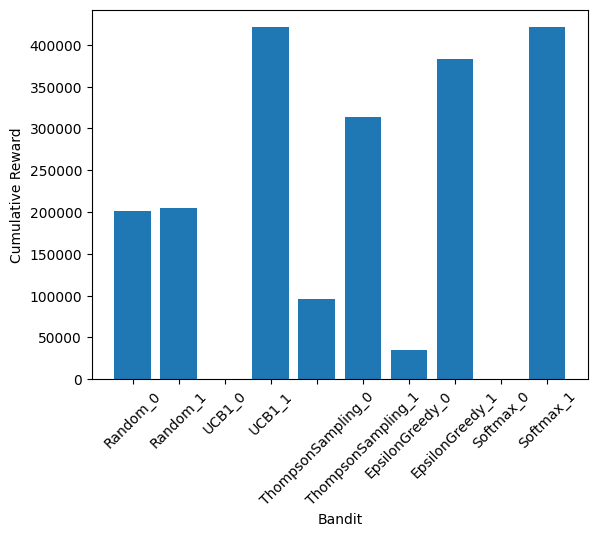

In [ ]:
####################################
# Context-Free Simulation
####################################
start = time()
sim = Simulator(context_free_mabs, decisions, rewards, contexts=None,
                scaler=None, test_size=0.5, is_ordered=False, batch_size=0, seed=123456)
sim.run()
end = time()

runtime = (end - start) / 60
print('Complete', str(runtime) + ' minutes')
print('\n')

for mab_name, mab in sim.bandits:
    print(mab_name)

    print('Worst Case Scenario:', sim.bandit_to_arm_to_stats_min[mab_name])
    print('Average Case Scenario:', sim.bandit_to_arm_to_stats_avg[mab_name])
    print('Best Case Scenario:', sim.bandit_to_arm_to_stats_max[mab_name])

    print('\n\n')

sim.plot('max', True)
# Vamos a plotear el best case scenario para todos los bandidos utilizados. El parámetro True indica que en el plot se va a plotear por separado cada "brazo"

### Actividad 3: Simulación "on-line" con contexto.

Basándose en el código anterior, vamos a repetir este experimento para los bandidos con contexto definidos anteriormente. Recuerde que los datos de contextos deben ser escalados, por lo que debe cambiar el parámetro scaler.

Esta simulación, a diferencia de la anterior, simulará un agente que se va actualizando de manera "on-line", en donde en cada iteración, los agentes reciben $100$ datos y en base a estos, actualizan sus políticas. Para hacer esto, solo debe modificar el parámetro de batch-size. Comente sus resultados

INFO:root:Simulation Parameters
2026-05-11 21:37:30,841 INFO Simulation Parameters
2026-05-11 21:37:30,841 INFO Simulation Parameters
2026-05-11 21:37:30,841 INFO Simulation Parameters
INFO:root:	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>), ('ThompsonSampling', <mabwiser.mab.MAB object at 0x7e23aa3cab40>), ('EpsilonGreedy', <mabwiser.mab.MAB object at 0x7e23a012e4e0>), ('Softmax', <mabwiser.mab.MAB object at 0x7e23a012ede0>)]
2026-05-11 21:37:30,846 INFO 	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>), ('ThompsonSampling', <mabwiser.mab.MAB object at 0x7e23aa3cab40>), ('EpsilonGreedy', <mabwiser.mab.MAB object at 0x7e23a012e4e0>), ('Softmax', <mabwiser.mab.MAB object at 0x7e23a012ede0>)]
2026-05-11 21:37:30,846 INFO 	 bandits: [('Random', <mabwiser.mab.MAB object at 0x7e23aa3cabd0>), ('UCB1', <mabwiser.mab.MAB object at 0x7e23aa3caae0>

Complete 0.02083506981531779 minutes


Random
Worst Case Scenario: {0: {'count': 235, 'sum': np.int64(37806), 'min': np.int64(12), 'max': np.int64(937), 'mean': np.float64(160.87659574468086), 'std': np.float64(249.92835927799342)}, 1: {'count': 265, 'sum': np.int64(43324), 'min': np.int64(3), 'max': np.int64(989), 'mean': np.float64(163.4867924528302), 'std': np.float64(282.1359247140285)}}
Average Case Scenario: {0: {'count': 235, 'sum': np.float64(114359.40522875814), 'min': np.float64(12.0), 'max': np.float64(937.0), 'mean': np.float64(486.6357669308857), 'std': np.float64(146.4496626595031)}, 1: {'count': 265, 'sum': np.float64(136782.0), 'min': np.float64(17.0), 'max': np.float64(989.0), 'mean': np.float64(516.1584905660377), 'std': np.float64(177.34230456834197)}}
Best Case Scenario: {0: {'count': 235, 'sum': np.int64(191509), 'min': np.int64(12), 'max': np.int64(996), 'mean': np.float64(814.931914893617), 'std': np.float64(294.6005366856655)}, 1: {'count': 265, 'sum': np.int64(

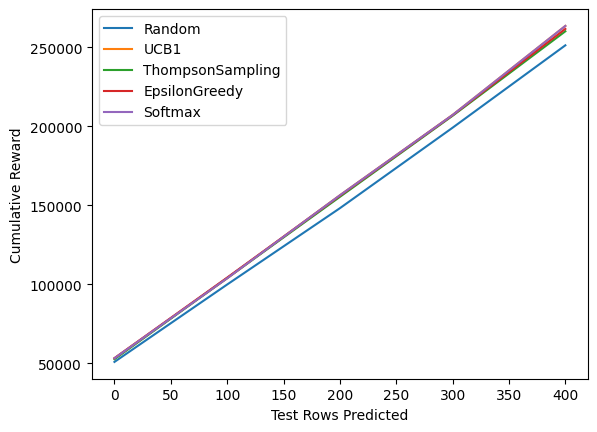

In [ ]:
start = time()
sim = Simulator(context_free_mabs, decisions, rewards, contexts=None,
                scaler=None, test_size=0.5, is_ordered=False, batch_size=100, seed=123456)
sim.run()
end = time()

runtime = (end - start) / 60
print('Complete', str(runtime) + ' minutes')
print('\n')

for mab_name, mab in sim.bandits:
    print(mab_name)

    # Como esta simulación es online, se debe específicar que imprima el valor 'total'
    print('Worst Case Scenario:', sim.bandit_to_arm_to_stats_min[mab_name]['total'])
    print('Average Case Scenario:', sim.bandit_to_arm_to_stats_avg[mab_name]['total'])
    print('Best Case Scenario:', sim.bandit_to_arm_to_stats_max[mab_name]['total'])

    print('\n\n')

sim.plot('avg', False)
# Como buscamos ahora maximizar el revenue, no separaremos los resultados por brazo, sino que se graficará de manera conjunta el revenue promedio obtenido por cada agente.

La simulación online procesa los 500 datos de test en 5 batches de 100, actualizando cada agente tras cada lote. Se observan varios patrones relevantes:
El gráfico de Cumulative Reward muestra que UCB1 y Softmax lideran con la mayor recompensa acumulada a lo largo de los 400 test rows predichos, seguidos muy de cerca por ThompsonSampling y EpsilonGreedy, mientras que Random queda levemente por debajo. Sin embargo, las diferencias son pequeñas porque todas las curvas son casi paralelas y lineales, lo que es consistente con el hecho de que los rewards son aleatorios y no hay estructura contextual real que explotar. En un entorno con señal verdadera, las diferencias entre políticas serían mucho más pronunciadas.
